In [28]:
import pandas as pd
import plotly.io as pio
import polars as pl

from wjp_judicial_independence.config import PATH_DATA_INTERIM
from wjp_judicial_independence.analysis import compare_strategies
from wjp_judicial_independence.plot import *

MODULE3_CACHE = PATH_DATA_INTERIM / "module3"

# Helpers para cargar figuras precargadas

def load_figure(key: str):
    """Load a pre-computed Plotly figure from JSON."""
    path = MODULE3_CACHE / f"fig_{key}.json"
    return pio.from_json(path.read_text())


def load_tpc(cache_key: str) -> pd.DataFrame:
    """Load a pre-computed topics_per_class DataFrame."""
    return pd.read_parquet(MODULE3_CACHE / f"tpc_{cache_key}.parquet")

# Visualización
Los objetivos de este módulo son:
1. Visualizar la distribución de temas identificados en el Módulo II por país. Es
importante, a la vez, comparar el "sentimiento" de la independencia judicial
entre Italia, Hungría y Polonia basándose en los datos.
2. Ver una lista de eventos críticos detectados por tu sistema.
3. Incluir un análisis crítico de los resultados
4. Añadir un análisis de la calidad de los datos y de las limitaciones del sistema.
5. (Bono) Si este sistema tuviera que escalar para procesar 50 países y 100 veces más noticias, ¿qué
cambios introducirías en la arquitectura para garantizar eficiencia y robustez? ¿Qué
estrategias implementarías específicamente para optimizar costos computacionales y de
uso de modelos (por ejemplo, LLMs o embeddings)?


In [29]:
# Cambiar la estrategia de clasificación de noticias de independencia judicial
MODULE1_STRATEGY = "embeddings"  # opciones: "llm" | "llm-api" | "embeddings"

In [30]:
df = pl.read_parquet(
    PATH_DATA_INTERIM
    / f"module2/sentiment/df_m1_{MODULE1_STRATEGY}_strategy_judicial_independence.parquet"
)

# 1. Distribución de Temas
### 1.1 Distribución de Temas generales de Independencia Judicial

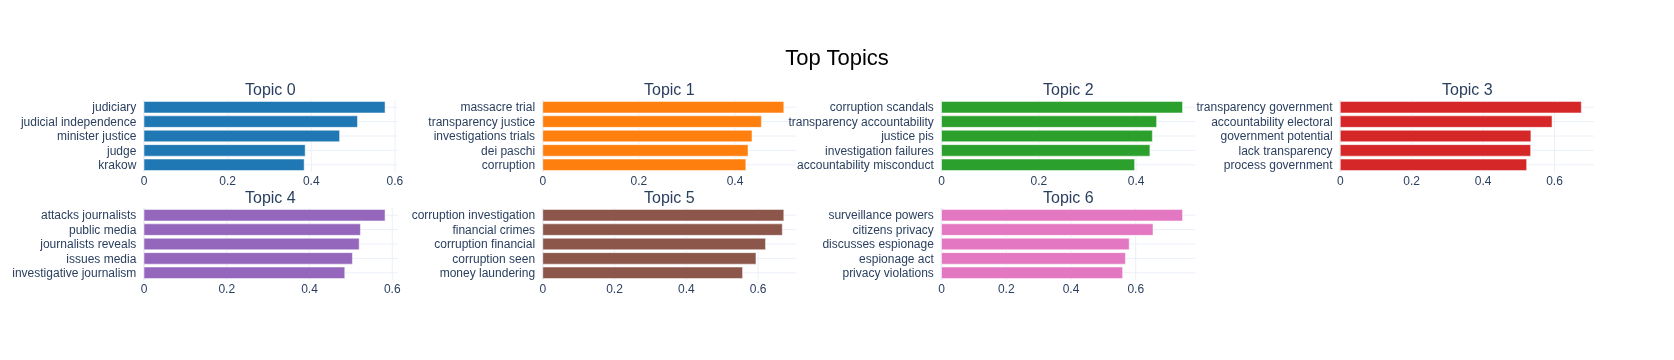

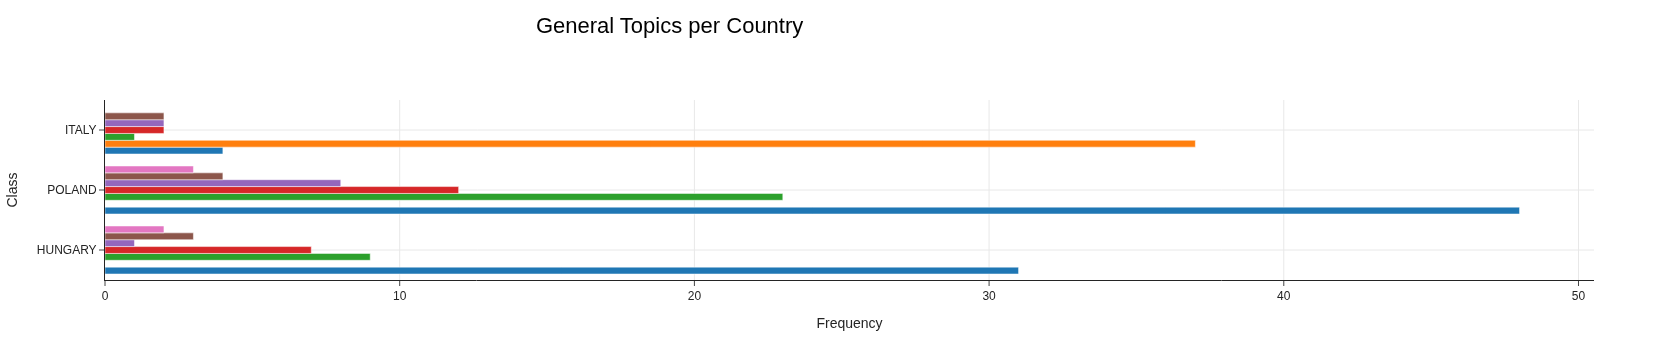

In [31]:
fig_bar_general = load_figure(f"bar_general_{MODULE1_STRATEGY}")
fig_bar_general.update_layout(width=None, height=None)
fig_bar_general.show()

fig_tpc_country = load_figure(f"tpc_general_{MODULE1_STRATEGY}_country")
fig_tpc_country.update_layout(width=None, height=None)
fig_tpc_country.show()

### 1.2 Comparación del Sentimiento de Independencia Judicial por País

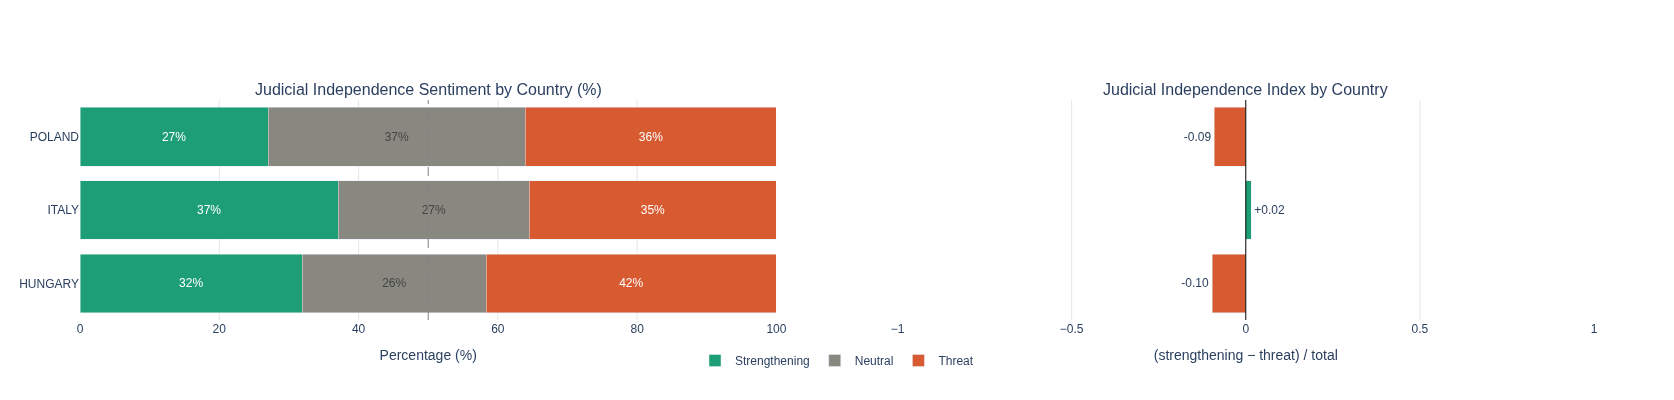

In [32]:
fig = plot_ji_sentiment(df)

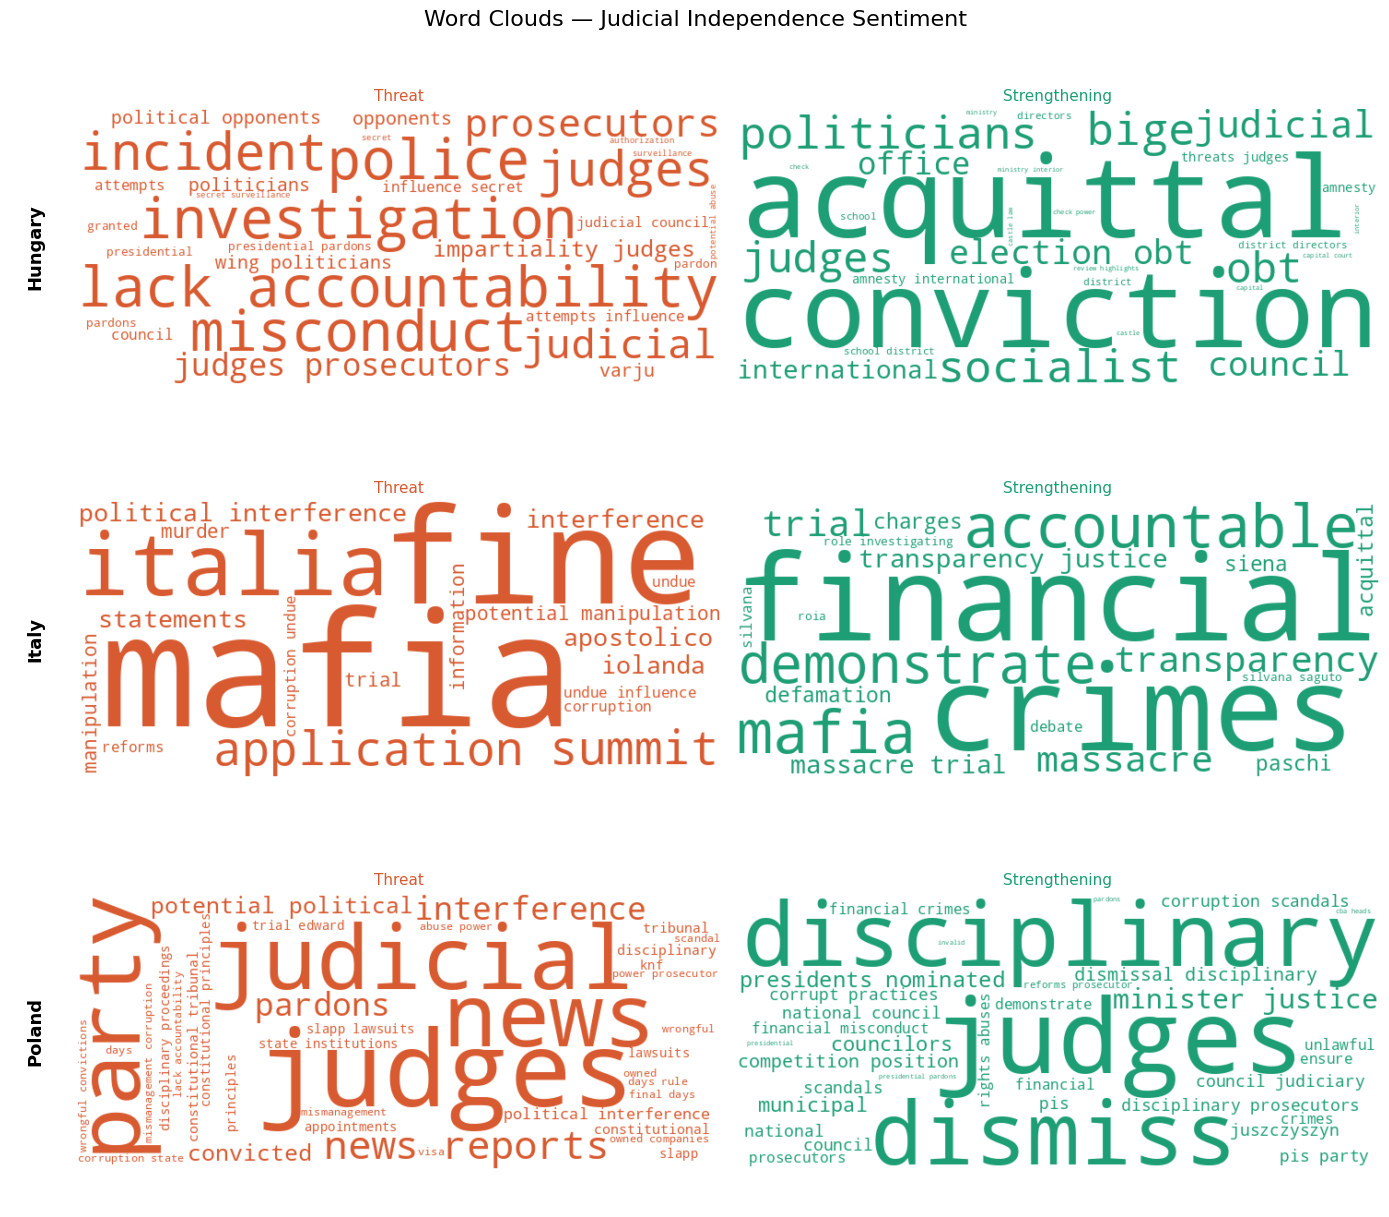

In [33]:
COUNTRIES = ["HUNGARY", "ITALY", "POLAND"]

topics_per_class_per_country = [
    (load_tpc(f"{country}_{MODULE1_STRATEGY}_sentiment"), country)
    for country in COUNTRIES
]

plot_sentiment_wordclouds(topics_per_class_per_country)

### 1.3 Temas de Independencia Judicial Detallado por País

Cambiar la variable `COUNTRY` para ver como cambian los temas de Independencia Judicial que se hablan dentro cada país

In [34]:
COUNTRY = "POLAND"  # "POLAND" | "ITALY" | "HUNGARY"

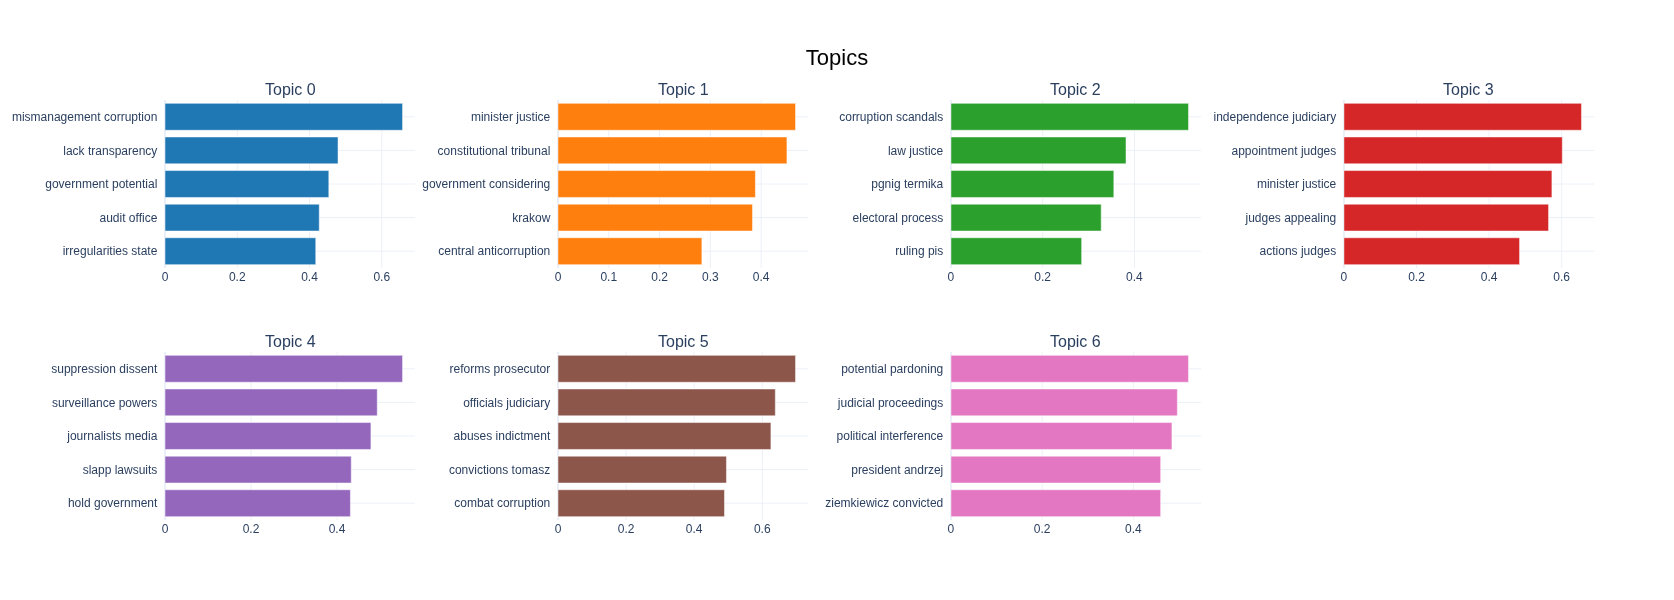

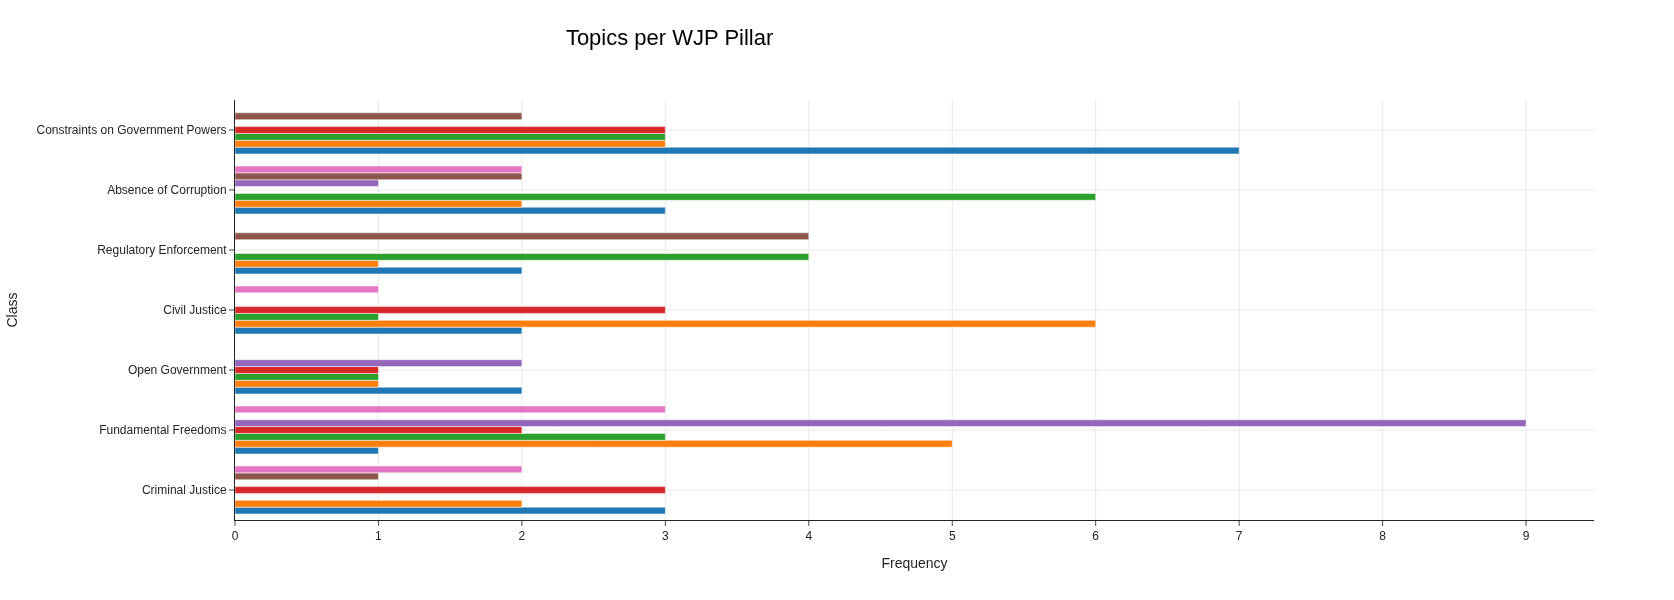

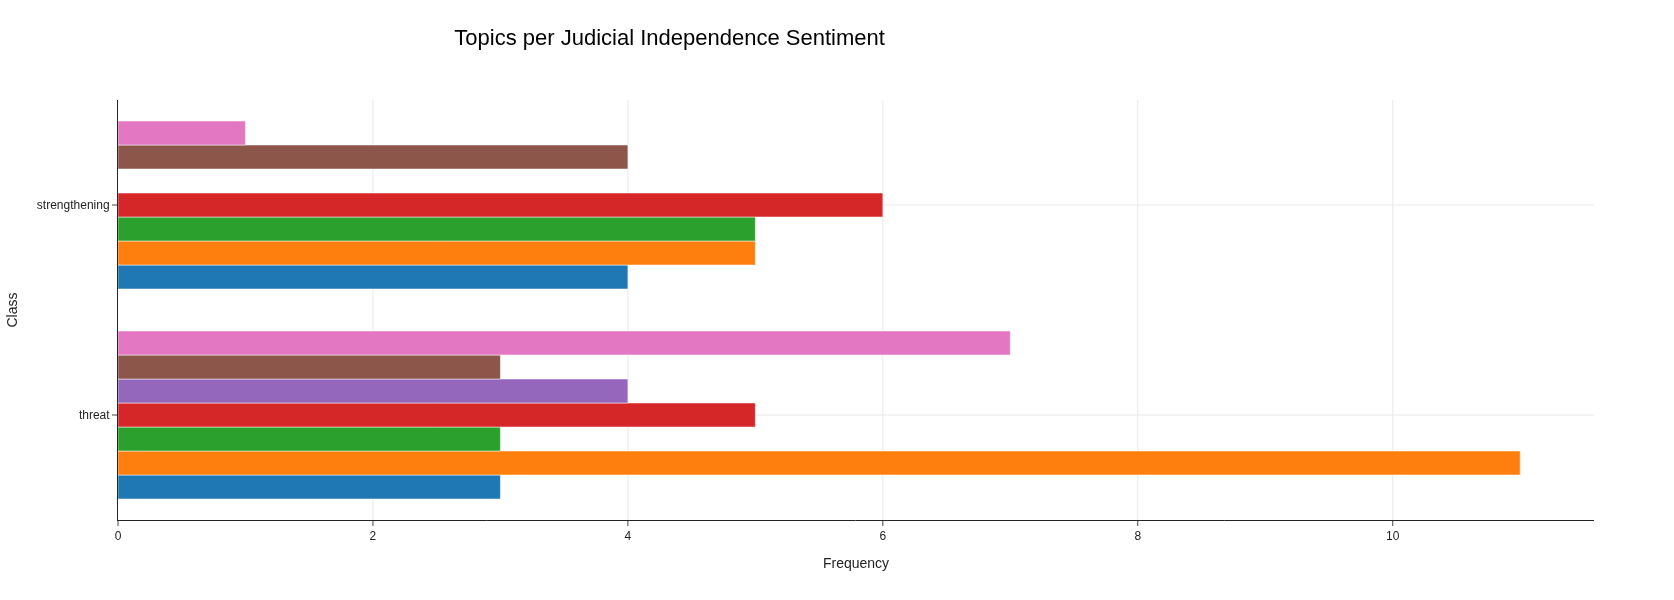

In [35]:
fig_bar = load_figure(f"bar_{COUNTRY}_{MODULE1_STRATEGY}")
fig_bar.update_layout(width=None, height=600)
fig_bar.show()

fig_tpc_pillar = load_figure(f"tpc_{COUNTRY}_{MODULE1_STRATEGY}_pillar")
fig_tpc_pillar.update_layout(width=None, height=600)
fig_tpc_pillar.show()

fig_tpc_sentiment = load_figure(f"tpc_{COUNTRY}_{MODULE1_STRATEGY}_sentiment")
fig_tpc_sentiment.update_layout(width=None, height=600)
fig_tpc_sentiment.show()

# 2. Eventos Críticos/Interesantes

### 2.1 Eventos Críticos

Eventos que tienen un puntaje alto en alguno de los indicadores de independencia judicial (basándose en la estrategia 1 del módulo 1)

In [36]:
TOP_EVENTS_PER_COUNTRY = 5

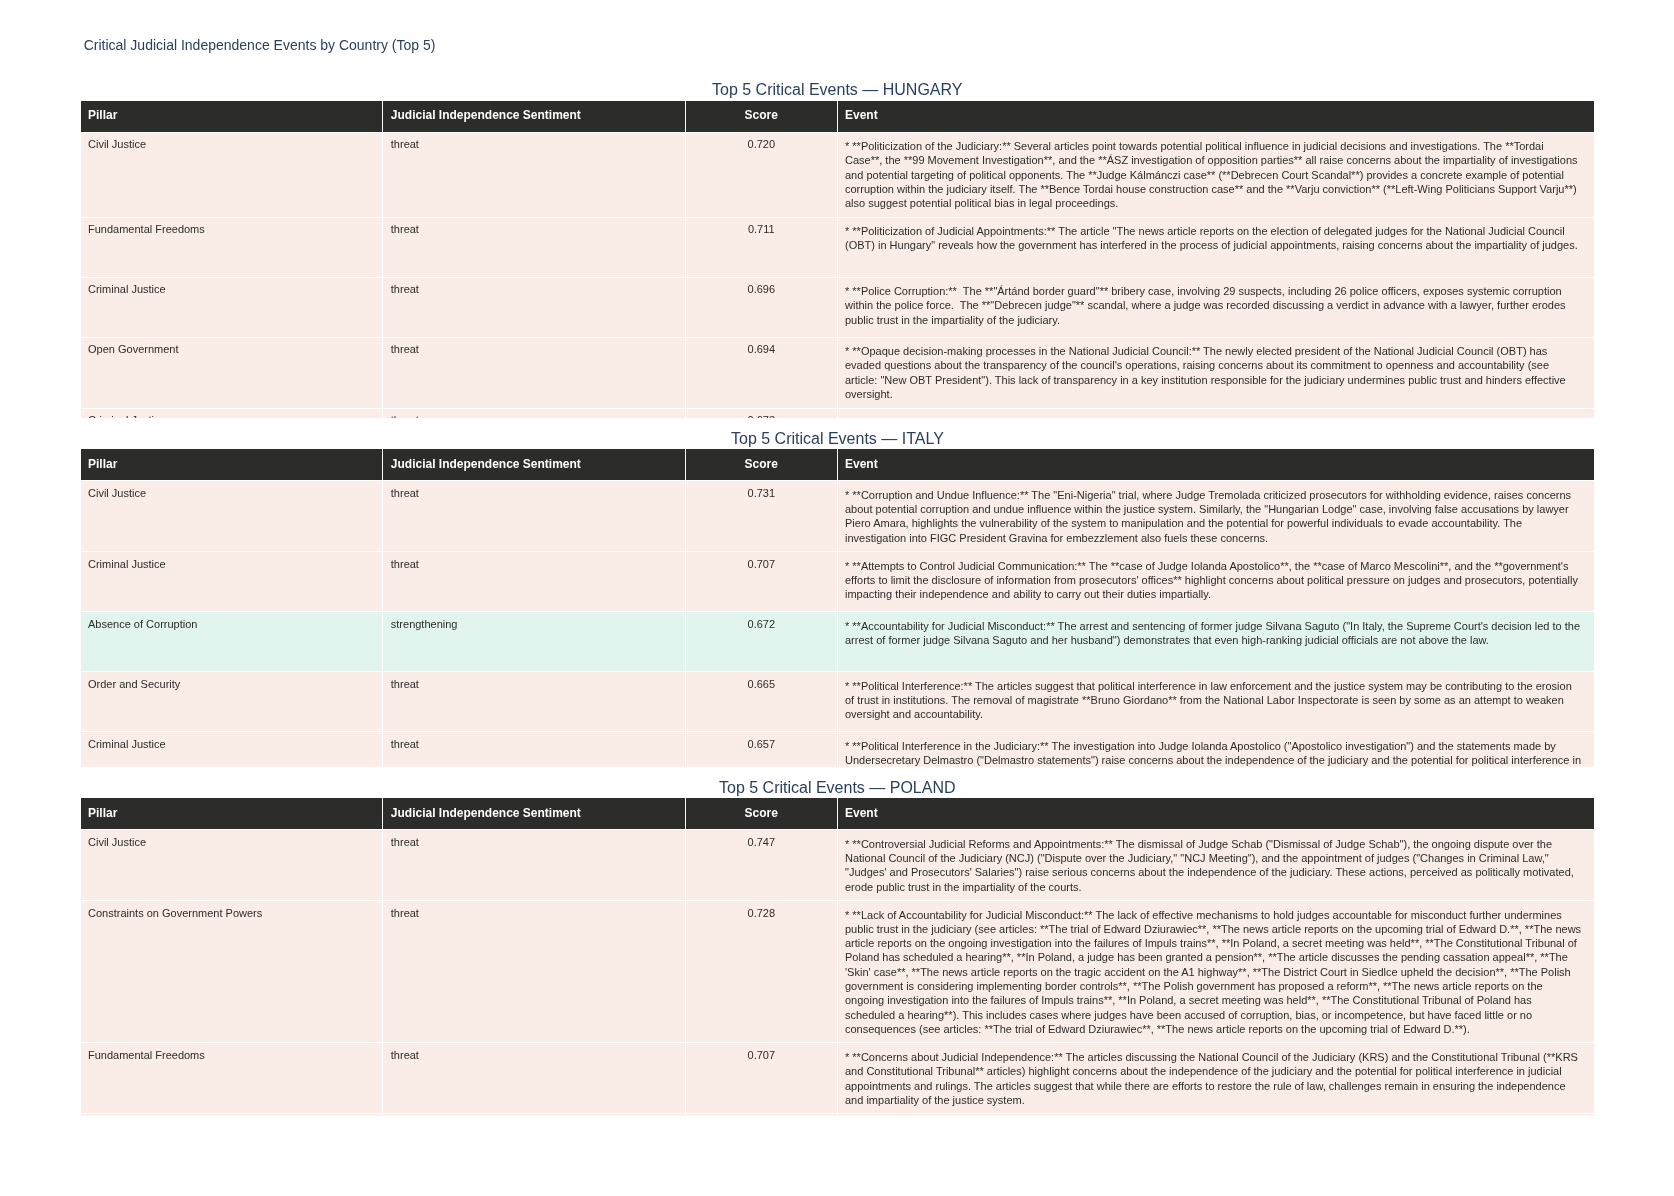

In [37]:
fig = plot_critical_events(df, top_n=TOP_EVENTS_PER_COUNTRY)

### 2.2 Eventos Interesantes

Eventos que tienen un impacto contrario/distinto al sentimiento de independencia judicial. Es decir:
- Noticias que tienen un impacto positivo en el pilar pero un sentimiento de independencia judicial negativo (amenaza)
- Noticias que tienen un impacto negativo en el pilar pero un sentimiento de independencia judicial positivo (fortalecimiento)
- Noticias que tienen un impacto neutral en el pilar pero un sentimiento de independencia judicial positivo/negativo (amenaza/fortalecimiento)

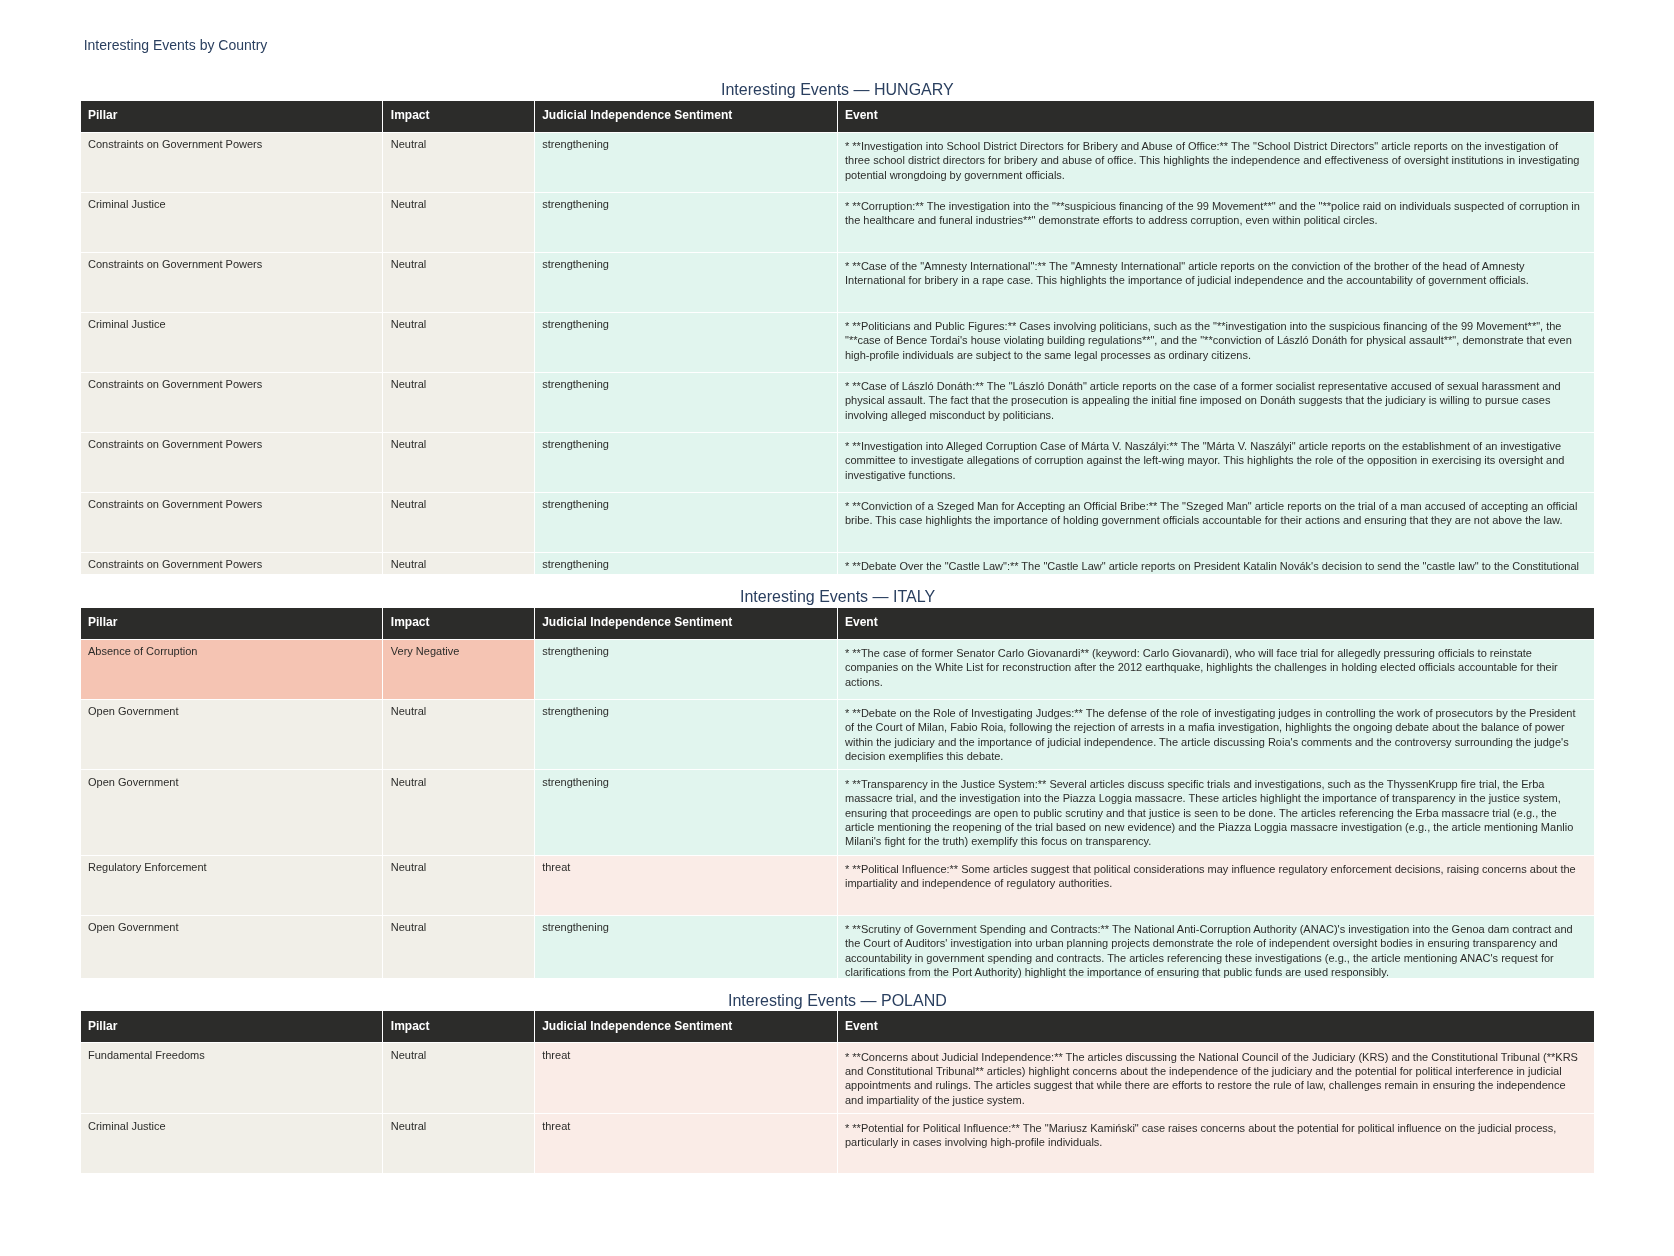

In [38]:
fig = plot_interesting_events(df)

# 3. Análisis de Resultados

## 3.1 Comparación de Estrategias de Clasificación de Noticias de Independencia Judicial

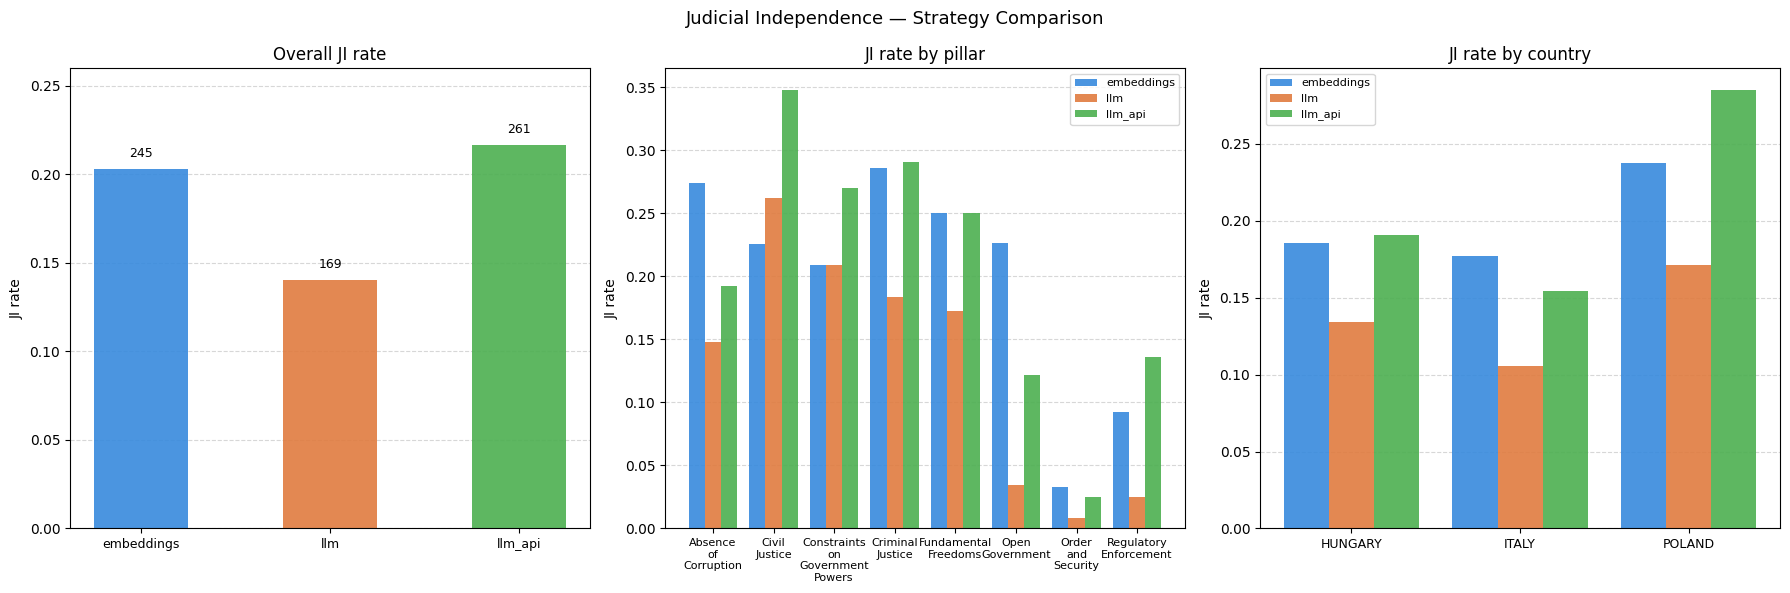

Similitud entre estrategias de clasificación:


,strategy_a,strategy_b,agreement_rate
0,embeddings,llm,0.825726
1,embeddings,llm_api,0.825726
2,llm,llm_api,0.892116


In [27]:
dfs = {
    "embeddings": pl.read_parquet(PATH_DATA_INTERIM / "module1/df_embeddings_strategy_judicial_independence.parquet"),
    "llm":        pl.read_parquet(PATH_DATA_INTERIM / "module1/df_llm_strategy_judicial_independence.parquet"),
    "llm_api":    pl.read_parquet(PATH_DATA_INTERIM / "module1/df_llm-api_strategy_judicial_independence.parquet"),
}

results = compare_strategies(dfs)

print("Similitud entre estrategias de clasificación:")
display(results["agreement"].to_pandas())

**Módulo 1 (clasificación).** Las estrategias suelen concordar en la clasificación pero no de forma totalmente robusta. Para hacer un mejor análisis se necesita una muestra de etiquetas manuales de algún experto del WJP que permita obtener métricas claras sobre cada estrategia. La ventaja principal de esta metodología es que es muy flexible: se pueden ajustar los prompts, los modelos (gratuitos o de pago), los hiperparámetros, los thresholds y las definiciones de referencia de independencia judicial, y con eso mejorar notoriamente los resultados. Eso sí, para hacer más experimentación se necesita un ground truth o métodos de investigación de experiencia de usuario (e.g., A/B testing) que permitan evaluar la calidad de las estrategias.

**Módulo 2a (sentimiento).** De forma similar, hace falta una muestra de noticias etiquetadas sobre sentimientos de independencia judicial para poder concluir algo sobre la calidad del clasificador. En la sección 2, al revisar los datos críticos e interesantes, a simple vista se observa una clasificación adecuada con fortalecimiento o amenaza a la independencia judicial. También es aconsejable analizar la experiencia de usuario y adecuar el clasificador a esta.

**Módulo 2b (temas).** Este es uno de los casos más retadores porque todas las noticias están asociadas con alguna forma de política y gobierno, entonces obtener temas consistentes y suficientemente distintos entre sí es un problema interesante. Los temas pueden variar dependiendo de la estrategia de clasificación de noticias de IJ que se use, pero los tópicos que recupera son relevantes y hace un buen trabajo diferenciando los temas a pesar de que todos contienen una dirección política similar. La estrategia de separar temas generales (usando todas las noticias de todos los países) y temas específicos por país es un aspecto positivo, ya que permite ver la variabilidad de independencia judicial dentro de cada país.

**Dashboard y visualización.** La estrategia de visualización (el notebook y/o la aplicación de Streamlit) es muy útil para un analista del WJP: permite reconocer los temas generales y qué tanto se habla de esos temas en cada país, con la diferencia de palabras clave de un mismo tema. También permite ver el análisis de sentimiento desde una perspectiva de puntaje y con los términos que más se mencionan de forma negativa/positiva diferenciando por país. Además incluye la visualización de tablas de eventos críticos (los que tienen más impacto a alguna de las 3 referencias de independencia judicial según la documentación técnica) y los eventos interesantes, que son los eventos cuyo impacto en un pilar no concuerda con el sentimiento de independencia judicial.

# 4. Análisis de la calidad de los datos y limitaciones del sistema

Lastimosamente los datos de los JSON no son noticias completas; contienen resúmenes, conclusiones e información poco relevante que puede dispersar la calidad de los resultados. En el módulo 1 se intentó filtrar la información no necesaria, pero sería mejor contar con noticias completas o resúmenes más extensos.
El sistema está limitado principalmente por restricciones computacionales que se podrían hacer más eficientes (lo menciono en el bono más adelante) y por la disponibilidad de GPU para procesar algunos modelos más rápido. Hace falta mucha más experimentación con otras metodologías para mejorar el sistema. La limitación más importante es la falta de etiquetas en los datos. Con etiquetas no solo se podrían explorar otras estrategias como fine-tuning de modelos de clasificación con embeddings o implementar nuevos modelos de ML, sino que también se tendrían métricas robustas de la calidad de la solución.

# 5. Bono: 

Si el sistema tuviera que procesar 50 países y 100 veces más noticias, lo primero sería definir bien la arquitectura y el flujo de datos, por ejemplo usando una arquitectura Medallion, y tener claro qué se quiere visualizar para construir los dashboards finales. A partir de ahí se pueden introducir bases de datos vectoriales en el flujo para almacenar embeddings y no tener que recomputarlos cada vez.
En cuanto a experimentación, en este proyecto se hizo de forma muy manual, pero se podría automatizar con herramientas como MLFlow para probar más modelos e ideas de forma estándar. Por el lado de costos, en esta arquitectura se usó el modelo de chat de pago de OpenAI, pero si se mantiene una estrategia de pago para obtener mejores resultados, usar el modo Batch puede reducir hasta un 50% los costos de procesamiento. Esto tiene sentido porque la herramienta no parece necesitar respuestas inmediatas, así que el modo en tiempo real no es necesario.